# Line fitting
Line fitting is a fundamental task in computer vision and image processing. It involves finding the best-fitting line that represents a set of data points. This process is useful in various applications, such as lane detection in autonomous vehicles, object tracking, and edge detection.

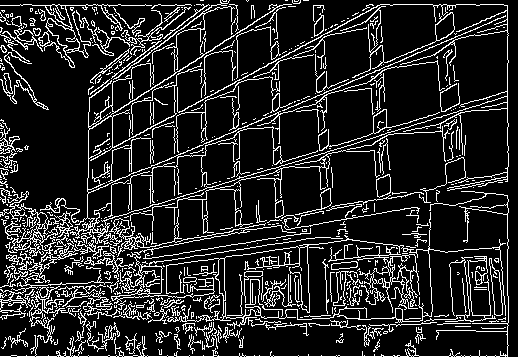

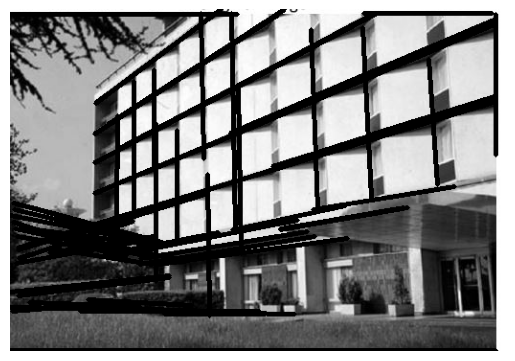

In [ ]:
#  This code reads the image, converts it to grayscale, applies edge detection using Canny,
# and then uses Hough Line Transform (cv2.HoughLinesP) to detect lines.
# Detected lines are drawn on the original image, and the result is displayed using Matplotlib.

import cv2
import numpy as np
from matplotlib import pyplot as plt
from google.colab.patches import cv_imshow
from google.colab.patches import cv2_imshow

path = r'/content/drive/MyDrive/CVClassLectureDemo/canny.JPG'

# Read the image in grayscale
image = cv2.imread(path, cv2.IMREAD_GRAYSCALE)  # Replace path with the path to your image

# Apply edge detection (you can use other edge detection methods as well)
edges = cv2.Canny(image, 50, 150, apertureSize=3)
cv_imshow(edges)
# Apply Hough Line Transform
lines = cv2.HoughLinesP(edges, 1, np.pi / 180, threshold=100, minLineLength=100, maxLineGap=10)

# Draw detected lines on the image
for line in lines:
    x1, y1, x2, y2 = line[0]
    #cv.Line(img, pt1, pt2, color, thickness)
    cv2.line(image, (x1, y1), (x2, y2), (0, 0, 255), 4)

# Display the result
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#Circle detection in images using Hough Transforms:
You are required to detect the circles in the given image. Your program should estimate and mark the position of the circles, present in the image. The estimation of circles should be done through Hough Transform, implemented from scratch.

Computing object properties, morphological operations, and connected components.

Original Image


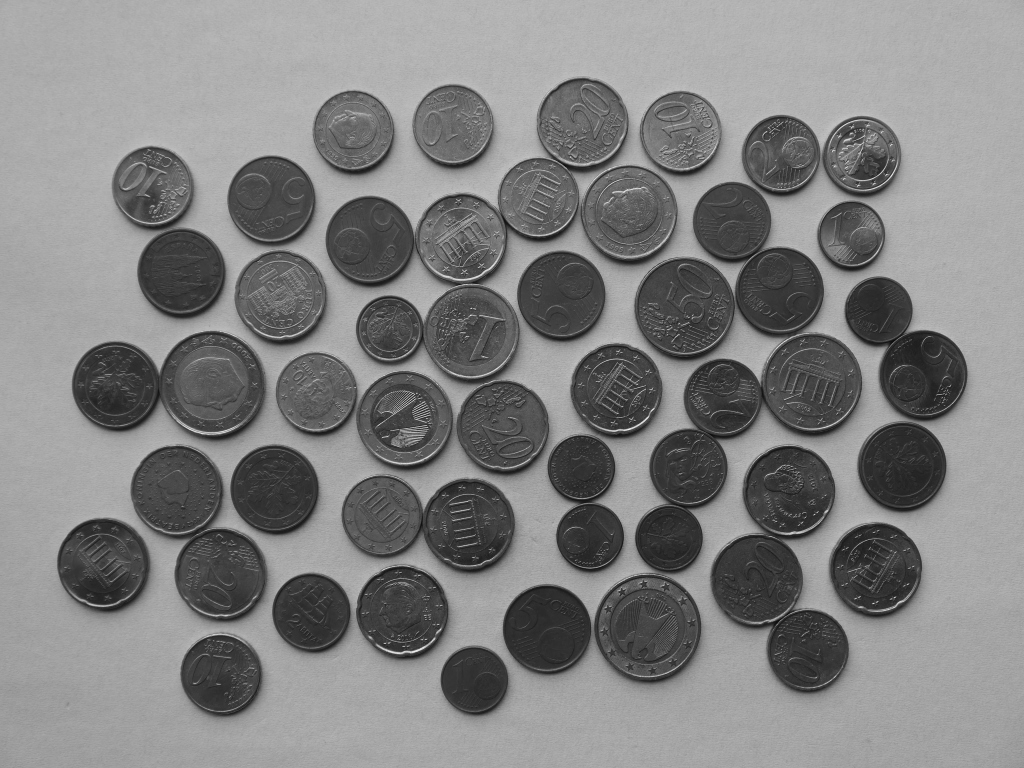

detected circles


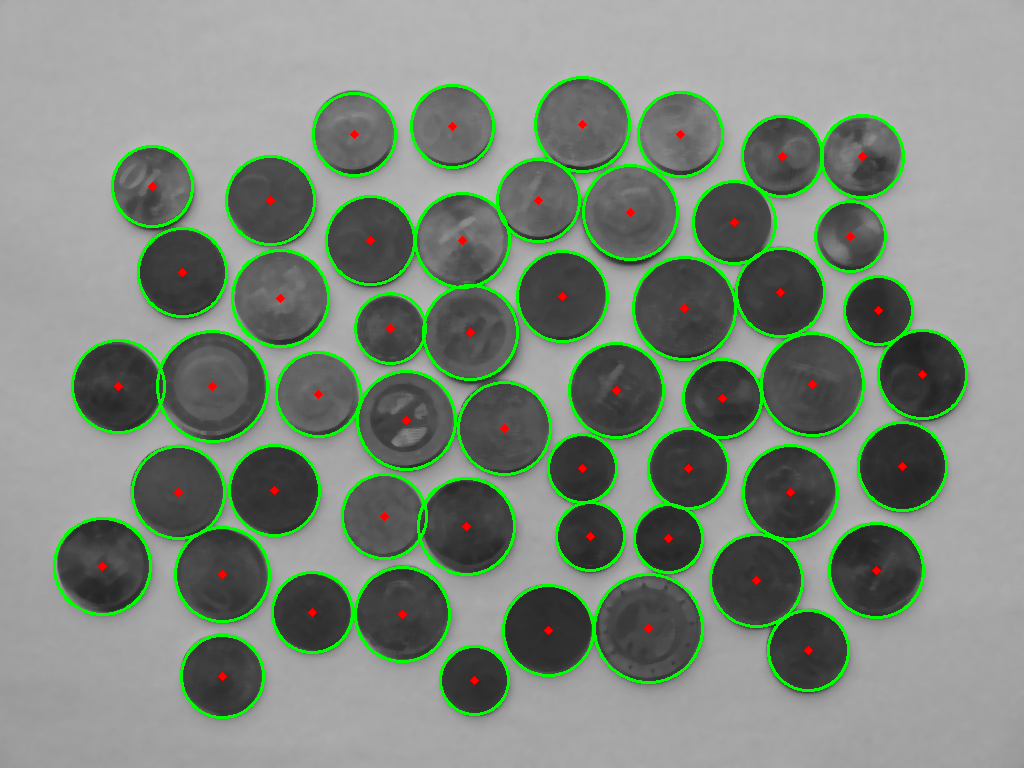

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
path = r'/content/drive/MyDrive/CVClassLectureDemo/coin.jpg'

# Read the image in grayscale
image = cv2.imread(path, cv2.IMREAD_GRAYSCALE)  # Replace path with the path to your image
print('Original Image')
cv2_imshow(image)

# Apply blur and Hough Circle Transform
blur = cv2.medianBlur(image, 7)  # Apply median blur to reduce noise
cimg = cv2.cvtColor(blur, cv2.COLOR_GRAY2BGR)
rows = blur.shape[0]
circles = cv2.HoughCircles(blur, cv2.HOUGH_GRADIENT, dp=1, minDist = rows/16, param1=100, param2=30, minRadius=10, maxRadius=90)

# Draw detected circles on the image
if circles is not None:
    circles = np.uint16(np.around(circles))
    for i in circles[0, :]:
      # draw the outer circle
      cv2.circle(cimg,(i[0],i[1]),i[2],(0,255,0),2)
      # draw the center of the circle
      cv2.circle(cimg,(i[0],i[1]),2,(0,0,255),3)

# Display the result
print('detected circles')
cv2_imshow(cimg)
